# 06. Pattern-Adaptive GB for Missing Feature Groups

## Goal

This notebook is a **separate research extension**, not a replacement for the main prediction pipeline.

- The **main pipeline** can reasonably stop at:  
  **03 Model Selection → 04 Stress Benchmark → 05 Final Prediction + SHAP**
- This notebook asks a **new method question** inspired by Bertsimas et al.:  

> If the model becomes fragile when an important feature group is unavailable, should we force one single model to handle all cases, or should the prediction rule **adapt to the observed feature pattern**?

Here I test a simple tabular analogue of **finitely adaptive prediction**:
- one full-feature Gradient Boosting model for the clean scenario
- plus fallback GB models for specific missing-feature patterns
- and routing at prediction time according to which feature groups are unavailable


## Why this extension is motivated

Two earlier results motivate this notebook:

1. **Stress benchmark:** the GB model showed non-trivial degradation under feature-group ablation.  
2. **Final SHAP results:** the final model relies heavily on structural variables and interactions, and among the prominent individual drivers are **GarageArea, GarageCars, and TotalBsmtSF**. The SHAP bar chart highlights GarageArea and GarageCars explicitly, alongside TotalSF / OverallQual / GrLivArea / TotalBsmtSF. fileciteturn17file0turn17file14

So instead of masking arbitrary columns, I focus on two interpretable missing-feature patterns:
- **Garage-related features**
- **Basement-related features**

This is also consistent with the original stress protocol, which implemented feature-group ablation by dropping predefined groups of columns and re-evaluating performance. fileciteturn17file15


In [1]:
from pathlib import Path
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

for p in [PROJECT_ROOT, SRC_DIR]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
MODEL_DIR = PROJECT_ROOT / "results" / "models"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("ggplot")
sns.set_context("talk")

In [2]:
from adaptive_gb import evaluate_static_vs_adaptive

In [3]:
train_processed = pd.read_csv(DATA_DIR / "train_processed.csv")

X = train_processed.drop("SalePrice_log", axis=1).copy()
y = train_processed["SalePrice_log"].copy()

# same holdout split convention as the earlier robustness notebooks
from stress_utils import make_train_valid_split
X_train, X_valid, y_train, y_valid = make_train_valid_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

X_train shape: (1160, 275)
X_valid shape: (291, 275)


## Select missing-feature groups

I do **not** use the top SHAP variables mechanically.

Instead, I use two filters together:

- **Filter 1: benchmark evidence** — only groups that were already tested in the stress benchmark
- **Filter 2: interpretability evidence** — groups that still show up in the final model explanation

That leads to:
- **Garage**
- **Basement**

I do **not** include the quality–space interaction block here, even though it is globally important, because:
- it was not explicitly benchmarked as a missing-feature group in the earlier stress stage
- and dropping an engineered interaction block is less natural as a “realistic missing modality” than missing garage/basement information


In [4]:
feature_groups = {
    "Garage": ["Garage"],
    "Basement": ["Bsmt", "Basement"],
}

resolved = {}
for g, keywords in feature_groups.items():
    resolved[g] = [c for c in X_train.columns if any(k.lower() in c.lower() for k in keywords)]

pd.DataFrame({
    "group": list(resolved.keys()),
    "n_cols": [len(v) for v in resolved.values()],
    "example_cols": [", ".join(v[:5]) for v in resolved.values()]
})

,group,n_cols,example_cols
0,Garage,24,"GarageYrBlt, GarageCars, GarageArea, GarageAge..."
1,Basement,32,"BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF..."


## Pattern-adaptive design

This notebook compares **two prediction rules**:

### 1. Static impute-then-regress baseline
One full-feature GB model is trained once.  
When a feature group is missing at test time, the missing columns are filled with simple training medians and the same model is reused.

### 2. Finitely adaptive GB
Following the spirit of Bertsimas et al., prediction is treated as a two-stage problem:
- first observe which feature group is unavailable
- then apply a **pattern-specific fallback model**

This is a practical tree-based analogue of adaptive prediction with missing data, where the rule depends on the observed feature pattern instead of forcing one static model to solve every case equally well. Bertsimas et al. explicitly frame prediction with missing data as a two-stage adaptive optimization problem, allow the predictive rule to depend on the missingness pattern, and emphasize the trade-off between a static model and more adaptive but potentially more complex rules. fileciteturn17file6turn18file3turn18file15


In [5]:
scenario_results_df, scenario_rmse_compare_df, static_model, adaptive_model = evaluate_static_vs_adaptive(
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    feature_groups=feature_groups,
    use_pairwise_combos=True,
    random_state=42,
)

scenario_results_df.round(5)

,scenario,model_type,rmse,mae,r2
0,clean,GB_StaticImpute,0.11059,0.07402,0.91899
1,clean,GB_FinitelyAdaptive,0.11059,0.07402,0.91899
2,missing_garage,GB_StaticImpute,0.12419,0.08587,0.89782
3,missing_garage,GB_FinitelyAdaptive,0.11320,0.07720,0.91512
4,missing_basement,GB_StaticImpute,0.11912,0.07969,0.90600
5,missing_basement,GB_FinitelyAdaptive,0.11347,0.07620,0.91471
6,missing_garage_and_basement,GB_StaticImpute,0.13902,0.09460,0.87197
7,missing_garage_and_basement,GB_FinitelyAdaptive,0.11384,0.07971,0.91415


In [6]:
scenario_results_df.to_csv(TABLE_DIR / "adaptive_gb_scenario_results.csv", index=False)
scenario_rmse_compare_df.to_csv(TABLE_DIR / "adaptive_gb_rmse_compare.csv", index=False)

joblib.dump(static_model, MODEL_DIR / "adaptive_gb_static_impute.joblib")
joblib.dump(adaptive_model, MODEL_DIR / "adaptive_gb_finitely_adaptive.joblib")

print("[Saved] scenario tables and models")

[Saved] scenario tables and models


## Scenario-level RMSE comparison

This chart is the key result of the notebook.

Interpret it like this:
- On **clean/full-feature data**, the adaptive model should remain very close to the static baseline.
- On **missing-feature scenarios**, the adaptive model has a chance to do better because it switches to a dedicated fallback rule instead of forcing the full model to extrapolate through simple imputation.


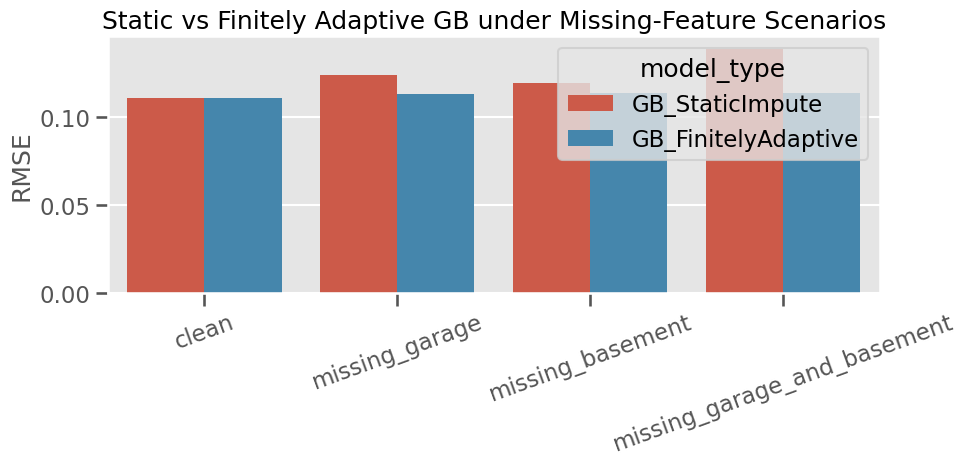

In [7]:
plot_df = scenario_results_df.copy()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x="scenario",
    y="rmse",
    hue="model_type",
    ax=ax
)
ax.set_title("Static vs Finitely Adaptive GB under Missing-Feature Scenarios")
ax.set_ylabel("RMSE")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()

fig.savefig(FIG_DIR / "adaptive_gb_scenario_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
scenario_rmse_compare_df.round(5)

model_type,scenario,GB_FinitelyAdaptive,GB_StaticImpute,adaptive_minus_static_rmse
0,clean,0.11059,0.11059,0.00000
1,missing_basement,0.11347,0.11912,-0.00566
2,missing_garage,0.11320,0.12419,-0.01100
3,missing_garage_and_basement,0.11384,0.13902,-0.02518


## Improvement relative to the static baseline

Negative values are better here, because they mean the adaptive rule reduced RMSE relative to the static impute-then-regress baseline.


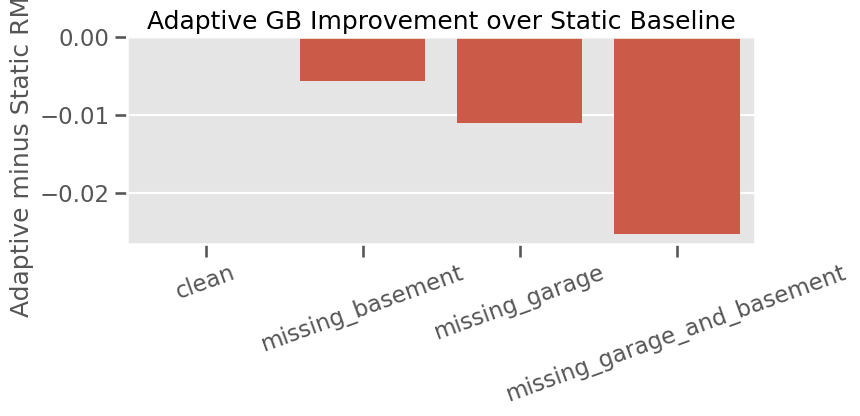

In [9]:
improve_df = scenario_rmse_compare_df.copy()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=improve_df,
    x="scenario",
    y="adaptive_minus_static_rmse",
    ax=ax,
    color=sns.color_palette()[0]
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Adaptive GB Improvement over Static Baseline")
ax.set_ylabel("Adaptive minus Static RMSE")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()

fig.savefig(FIG_DIR / "adaptive_gb_improvement.png", dpi=300, bbox_inches="tight")
plt.show()

## How to read the result

This notebook is successful if it shows the following pattern:

- **clean scenario stays essentially intact**
- **garage-missing and/or basement-missing scenarios improve**
- the improvement comes from **adaptivity**, not from sacrificing the full-information task

That is exactly the reason for moving this chapter **after** SHAP and final prediction.  
If this adaptive extension works, it becomes a **personal method exploration** on top of the main project.  
If it does not work perfectly, it still gives you a precise future direction:

> one model is not always the best solution for every missing-feature pattern.


## Suggested narrative for the interview

**What I tried here was not another generic data augmentation trick.**  
After finishing the main pipeline, I realized the remaining weakness was structured feature-group missingness.  
So instead of forcing one single GB to trade away clean RMSE for every perturbation scenario, I moved to a more adaptive idea inspired by Bertsimas et al.:  
I kept a strong full-feature model for the clean case, and trained separate fallback GB models for specific missing-feature patterns, then routed prediction according to which information was unavailable.

That means the intervention is no longer “make one model robust to everything,” but rather:

**match the prediction rule to the observed feature pattern.**
